## PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd

In [2]:
df_dqi =pd.read_csv('./Data/Processed/df_dqi_final.csv', sep=';')
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False


In [3]:
print(df_dqi.shape, df_dqi.columns)

(638, 37) Index(['folio_integrante', 'macronutrients_dqi', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories_dqi', 'total_fat_dqi',
       'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi',
       'dqi_food_groups', 'dqi_protein_sources', 'variety_dqi',
       'dqi_adequacy_fruits', 'dqi_adequacy_vegetables', 'dqi_adequacy_grains',
       'dqi_adequacy_fiber', 'dqi_adequacy_protein', 'dqi_adequacy_calcium',
       'dqi_adequacy_iron', 'dqi_adequacy_vitamin_c', 'dqi_adecuacy',
       'dqi_total', 'edad', 'ponderador', 'grupo',
       'resultado_general_entrevista', 'region_Centro', 'region_Centro Norte',
       'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')


In [4]:
# mostrar de manera vertical
pd.set_option('display.max_columns', 25)

df_dqi.describe()

,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,dqi_protein_sources,variety_dqi,dqi_adequacy_fruits,dqi_adequacy_vegetables,dqi_adequacy_grains,dqi_adequacy_fiber,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,resultado_general_entrevista
count,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,6.380000e+02,638.0
mean,0.796238,0.112853,0.909091,1.147335,1.034483,0.893417,4.123824,5.943574,13.142633,9.987461,3.515674,13.503135,2.564263,3.001567,0.699060,3.186520,4.805643,3.172414,2.952978,3.873041,24.255486,51.810345,39.985893,1.115890e+05,1.0
std,1.574677,0.513361,1.616597,1.977166,1.723073,1.678543,2.525604,0.472092,5.060392,4.200602,1.770748,5.539567,1.986163,1.892312,1.052931,1.633059,0.592867,1.476681,1.712723,1.631093,8.509977,12.880324,13.303537,1.340553e+05,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,19.000000,18.000000,7.032174e+03,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,9.000000,6.000000,3.000000,9.000000,1.000000,1.000000,0.000000,2.000000,5.000000,2.000000,1.000000,3.000000,18.000000,42.000000,28.000000,3.160034e+04,1.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,6.000000,12.000000,12.000000,5.000000,14.500000,2.000000,3.000000,0.000000,3.000000,5.000000,3.000000,3.000000,5.000000,25.000000,53.000000,40.000000,6.486087e+04,1.0
75%,0.000000,0.000000,2.000000,3.000000,3.000000,0.000000,6.000000,6.000000,15.000000,12.000000,5.000000,17.000000,5.000000,5.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,61.000000,51.000000,1.352364e+05,1.0
max,6.000000,4.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,30.000000,15.000000,5.000000,20.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,40.000000,84.000000,64.000000,1.145273e+06,1.0


Como podemos observar en el resultado anterior, tenemos 37 columnas y solo 638 registros, por lo cual será difícil para los modelos encontrar clusters en un espacio con tantas dimensiones y pocos registros. Es por esto que primero aplicaremos PCA para reducir la dimensionalidad de nuestro data set, tratando de mantener la mayor cantidad de variabilidad poisible.

In [5]:

## Eliminar columnas que no se utilizarán en el proceso de clustering
df_clustering_pca = df_dqi.copy()
df_clustering_pca.drop(columns=['folio_integrante', 'ponderador', 'grupo','resultado_general_entrevista'], inplace=True)


In [6]:
df_clustering_pca.columns

Index(['macronutrients_dqi', 'fatty_acids_dqi', 'balance_dqi',
       'empty_calories_dqi', 'total_fat_dqi', 'saturated_fat_dqi',
       'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi', 'dqi_food_groups',
       'dqi_protein_sources', 'variety_dqi', 'dqi_adequacy_fruits',
       'dqi_adequacy_vegetables', 'dqi_adequacy_grains', 'dqi_adequacy_fiber',
       'dqi_adequacy_protein', 'dqi_adequacy_calcium', 'dqi_adequacy_iron',
       'dqi_adequacy_vitamin_c', 'dqi_adecuacy', 'dqi_total', 'edad',
       'region_Centro', 'region_Centro Norte', 'region_Frontera',
       'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')

Aplicamos PCA a las columnas numéricas, las categóricas las excluimos de este proceso pero igual harán parte del data set final.

In [7]:
# Lista de columnas a las que se les aplicará PCA

cols_pca = ['macronutrients_dqi', 'fatty_acids_dqi', 'balance_dqi',
       'empty_calories_dqi', 'total_fat_dqi', 'saturated_fat_dqi',
       'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi', 'dqi_food_groups',
       'dqi_protein_sources', 'variety_dqi', 'dqi_adequacy_fruits',
       'dqi_adequacy_vegetables', 'dqi_adequacy_grains', 'dqi_adequacy_fiber',
       'dqi_adequacy_protein', 'dqi_adequacy_calcium', 'dqi_adequacy_iron',
       'dqi_adequacy_vitamin_c', 'dqi_adecuacy', 'dqi_total', 'edad']

In [8]:
# Crear el transformer para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler_pca', Pipeline([
            ('scaler', MinMaxScaler()),
            ('pca', PCA(n_components=0.9))
        ]), cols_pca),
        ('no_transform', 'passthrough', [col for col in df_clustering_pca.columns if col not in cols_pca])
    ]
)

# Crear el pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Ajustar el pipeline a los datos
df_transformed = pipeline.fit_transform(df_clustering_pca)

In [9]:
# Obtener el modelo PCA y ver resultados
pca_model = pipeline.named_steps['preprocessor'].named_transformers_['scaler_pca'].named_steps['pca']
print(f"Cantidad de componentes seleccionadas: {pca_model.n_components_}")
print(f"Porcentaje de varianza explicada: {pca_model.explained_variance_ratio_.sum() * 100:.2f}%")

# Crear DataFrame final con los datos transformados y sin transformar
pca_columns = [f"PC{i+1}" for i in range(pca_model.n_components_)]
non_pca_columns = [col for col in df_clustering_pca.columns if col not in cols_pca]
final_columns = pca_columns + non_pca_columns
df_clustering_pca = pd.DataFrame(df_transformed, columns=final_columns)

df_clustering_pca.head()


Cantidad de componentes seleccionadas: 10
Porcentaje de varianza explicada: 91.90%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,-0.587293,0.125022,-0.543732,-0.418945,-0.106454,0.091643,0.153976,-0.040388,-0.170410,-0.033183,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.966491,-0.308382,-0.146686,0.387938,0.094965,-0.106768,-0.435480,-0.128759,-0.040712,0.060743,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.005097,-0.165171,-0.351644,0.415040,0.381133,-0.065105,0.277553,-0.178965,-0.341074,0.049772,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.021594,-0.846509,0.239007,0.355802,-0.419847,0.026901,-0.163077,-0.384440,-0.336354,-0.020544,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.336719,-0.256966,0.016915,0.060767,0.091697,-0.281555,0.447879,-0.206277,-0.180261,-0.109531,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Según los resultados anteriores, seleccionando 18 componentes principales se logra explicar el 95% de la varianza de los datos. Por lo cual continuaremos con este dataset más reducido para realizar el clustering.

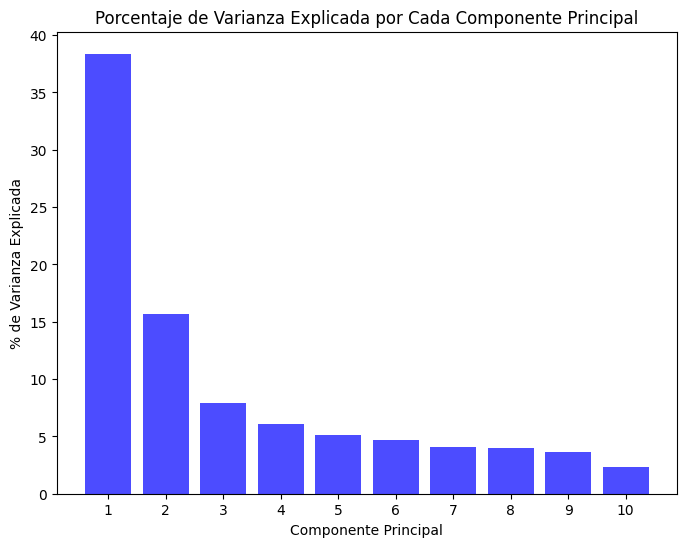

In [10]:

# 1. Graficar el porcentaje de varianza explicada por cada componente
plt.figure(figsize=(8, 6))
plt.bar(np.arange(1, pca_model.n_components_ + 1), pca_model.explained_variance_ratio_ * 100, alpha=0.7, color='b')

# Etiquetas y título
plt.title('Porcentaje de Varianza Explicada por Cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('% de Varianza Explicada')
plt.xticks(np.arange(1, pca_model.n_components_ + 1))  
plt.show()

In [11]:
## Exportar el dataset con las componentes principales
df_clustering_pca.to_csv('./Data/Processed/df_clustering_pca.csv', sep=';', index=False)